In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.python.keras.layers import Dense, Flatten
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam


In [ ]:

train_path = '/content/drive/MyDrive/bb/CSE299/Datasets/train'
valid_path = '/content/drive/MyDrive/bb/CSE299/Datasets/test'

In [ ]:
img_height, img_width = 256, 256  # Update image dimensions to match ResNet50 input size
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/drive/MyDrive/bb/CSE299/Datasets/test",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height, img_width),  # Update image size here
    batch_size=batch_size
)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/drive/MyDrive/bb/CSE299/Datasets/test",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),  # Update image size here
    batch_size=batch_size
)

Found 10099 files belonging to 8 classes.
Using 8080 files for training.
Found 10099 files belonging to 8 classes.
Using 2019 files for validation.


In [ ]:
class_names = train_ds.class_names
print(class_names)

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_healthy']


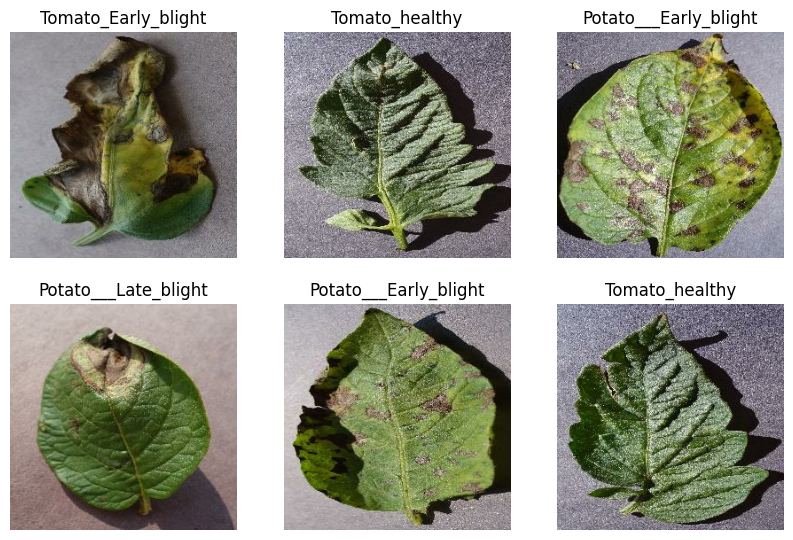

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(6):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [ ]:
resnet_model = Sequential()

pretrained_model= tf.keras.applications.ResNet50(include_top=False,
                   input_shape=(256,256,3),
                   pooling='avg',classes=8,
                   weights='imagenet')
for layer in pretrained_model.layers:
        layer.trainable=False

resnet_model.add(pretrained_model)
resnet_model.add(Flatten())
resnet_model.add(Dense(512, activation='relu'))
resnet_model.add(Dense(8, activation='softmax'))
resnet_model.add(Dense(8, activation='softmax'))

94765736/94765736 [==============================] - 0s 0us/step


In [ ]:
resnet_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 2048)              23587712  
                                                                 
 module_wrapper (ModuleWrap  (None, 2048)              0         
 per)                                                            
                                                                 
 module_wrapper_1 (ModuleWr  (None, 512)               1049088   
 apper)                                                          
                                                                 
 module_wrapper_2 (ModuleWr  (None, 8)                 4104      
 apper)                                                          
                                                                 
 module_wrapper_3 (ModuleWr  (None, 8)                 72        
 apper)                                                 

In [ ]:
resnet_model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [ ]:
epochs=10
history = resnet_model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/10
253/253 [==============================] - 2782s 11s/step - loss: 0.9988 - accuracy: 0.6011 - val_loss: 1.0376 - val_accuracy: 0.5820
Epoch 2/10
253/253 [==============================] - 2702s 11s/step - loss: 0.9548 - accuracy: 0.6036 - val_loss: 0.9773 - val_accuracy: 0.5939
Epoch 3/10
253/253 [==============================] - 2704s 11s/step - loss: 0.9256 - accuracy: 0.5999 - val_loss: 0.9456 - val_accuracy: 0.5939
Epoch 4/10
253/253 [==============================] - 2751s 11s/step - loss: 0.8919 - accuracy: 0.6017 - val_loss: 0.8980 - val_accuracy: 0.6003
Epoch 5/10
253/253 [==============================] - 2740s 11s/step - loss: 0.8437 - accuracy: 0.6130 - val_loss: 0.9007 - val_accuracy: 0.6122
Epoch 6/10
253/253 [==============================] - 2738s 11s/step - loss: 0.8363 - accuracy: 0.6205 - val_loss: 0.8731 - val_accuracy: 0.6077
Epoch 7/10
253/253 [==============================] - 2751s 11s/step - loss: 0.8176 - accuracy: 0.6214 - val_loss: 0.8321 - val_ac

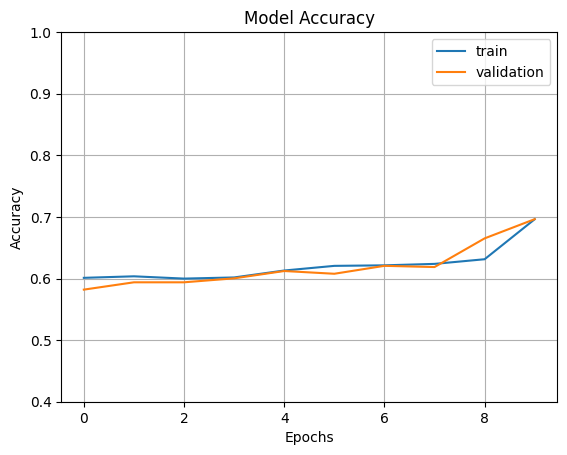

In [ ]:
fig1 = plt.gcf()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.axis(ymin=0.4,ymax=1)
plt.grid()
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'])
plt.show()

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.grid()
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'])
plt.show()

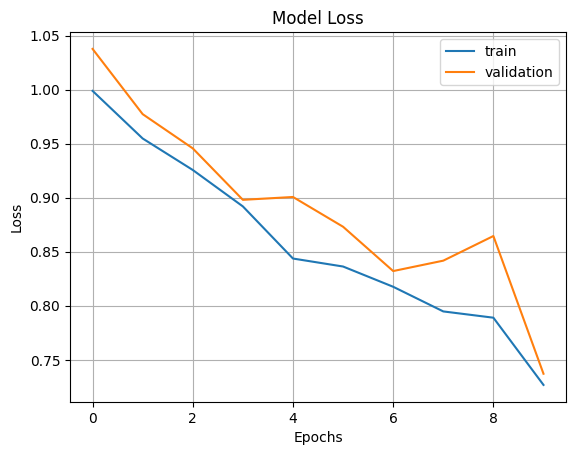

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.grid()
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')
plt.legend(['train', 'validation'])
plt.show()

first image to predict
actual label: Tomato_Late_blight
1/1 [==============================] - 11s 11s/step
predicted label: Tomato_Late_blight


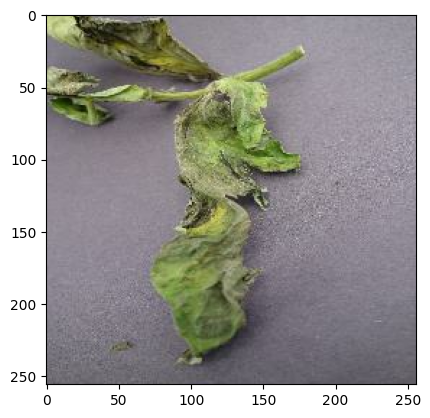

In [ ]:
import numpy as np
for images, labels in train_ds.take(1):

    first_image = images[0].numpy().astype('uint8')
    first_label = labels[0].numpy()

    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:",class_names[first_label])

    batch_prediction = resnet_model.predict(images)
    print("predicted label:",class_names[np.argmax(batch_prediction[0])])

In [ ]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i].numpy())
    img_array = tf.expand_dims(img_array, 0)

    predictions = resnet_model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

1/1 [==============================] - 0s 241ms/step


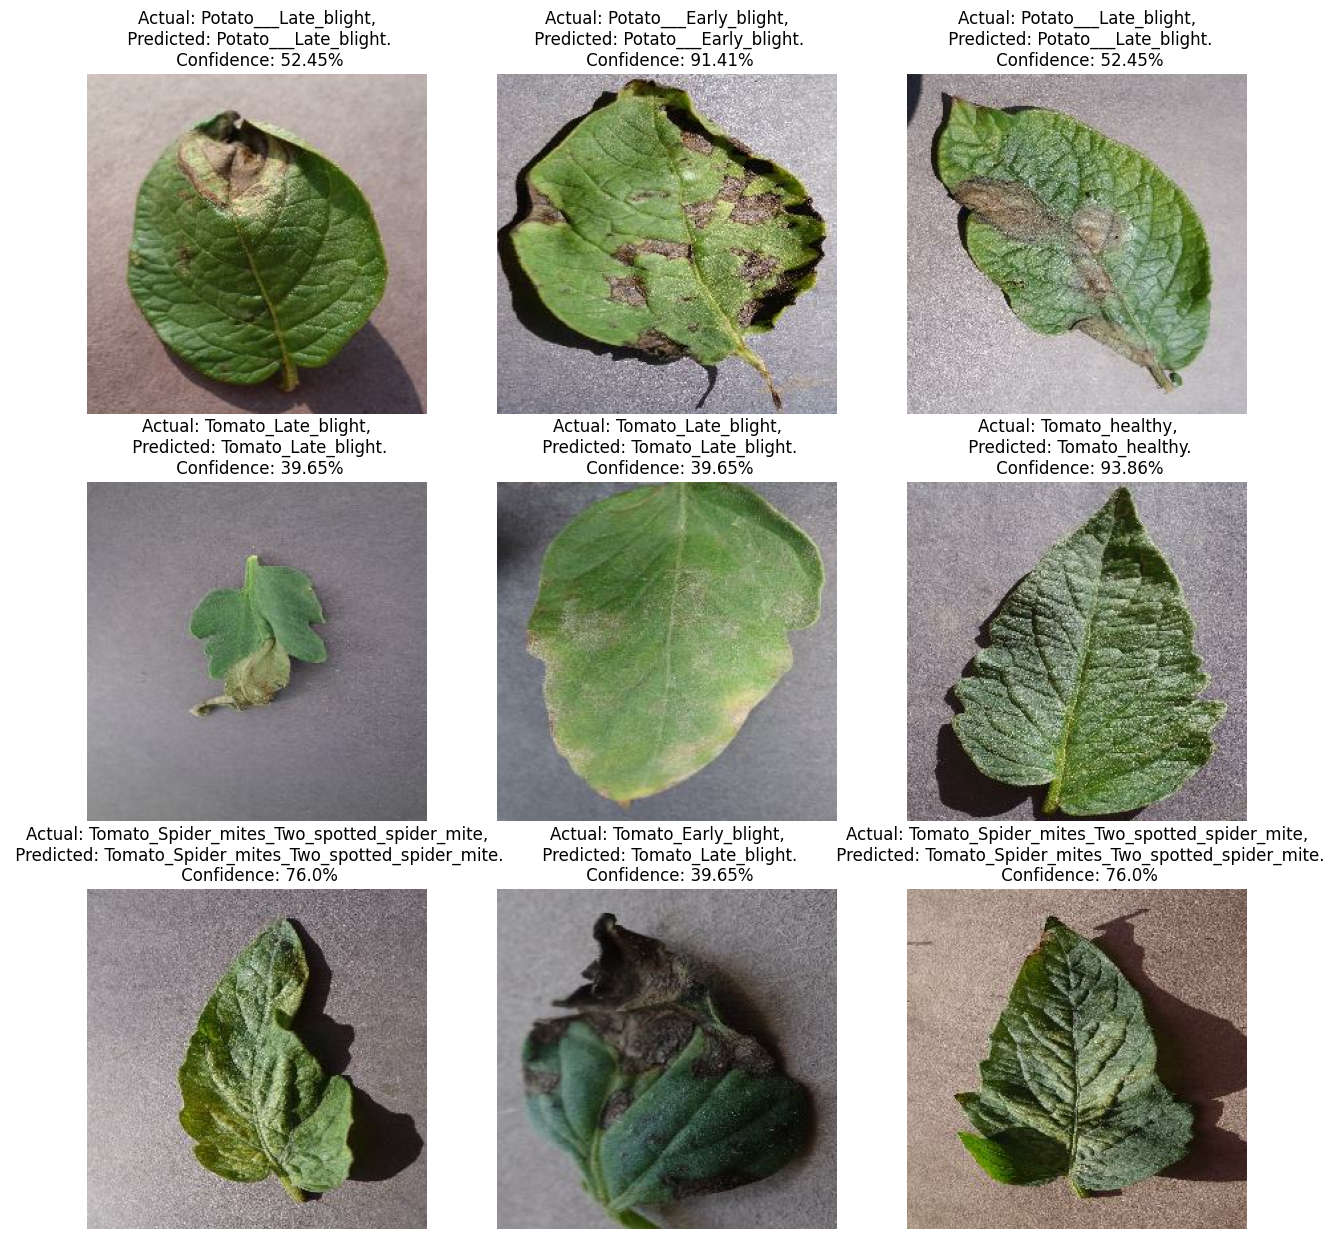

In [ ]:
plt.figure(figsize=(15, 15))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))

        predicted_class, confidence = predict(resnet_model, images[i].numpy())
        actual_class = class_names[labels[i]]

        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")

        plt.axis("off")